Batch 0:
  Labels: [{'boxes': tensor([[ 37.7263, 184.4657, 218.3490, 334.3689]]), 'labels': tensor([2]), 'image_id': 'img_e3cb2ead853a.jpg'}, {'boxes': tensor([], size=(0, 4)), 'labels': tensor([], dtype=torch.int64), 'image_id': 'img_e63e107bc0f4.jpg'}, {'boxes': tensor([[131.6715, 116.1818, 400.5239, 333.0000]]), 'labels': tensor([0]), 'image_id': 'img_a9722a96728b.jpg'}, {'boxes': tensor([], size=(0, 4)), 'labels': tensor([], dtype=torch.int64), 'image_id': 'img_061152da50ce.jpg'}, {'boxes': tensor([[ 59.0000,  11.0000, 326.0000, 441.0000]]), 'labels': tensor([2]), 'image_id': 'img_28c692528e88.jpg'}, {'boxes': tensor([[1.7255e+02, 1.8097e-01, 5.0000e+02, 3.8900e+02]]), 'labels': tensor([0]), 'image_id': 'img_520b494ba369.jpg'}, {'boxes': tensor([[ 70.0000,   1.0000, 499.0000, 375.0000]]), 'labels': tensor([2]), 'image_id': 'img_a94bb9af3a78.jpg'}, {'boxes': tensor([[ 55.4371,  70.6495, 329.2225, 436.0000]]), 'labels': tensor([3]), 'image_id': 'img_04f05e53d56e.jpg'}]


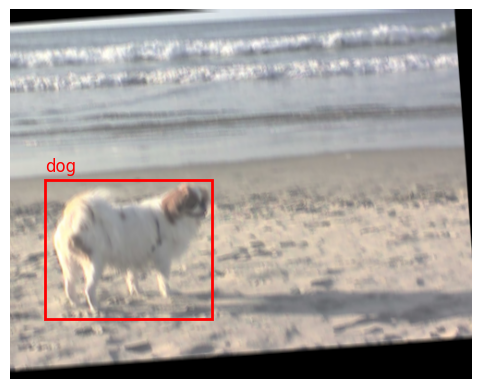

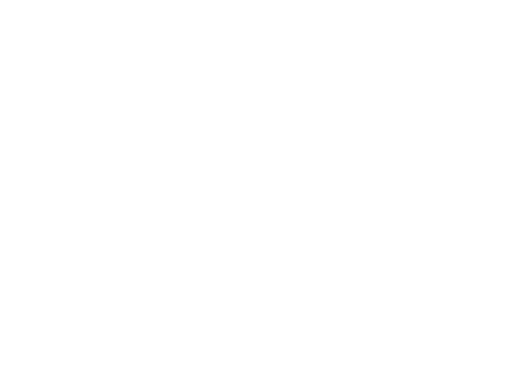

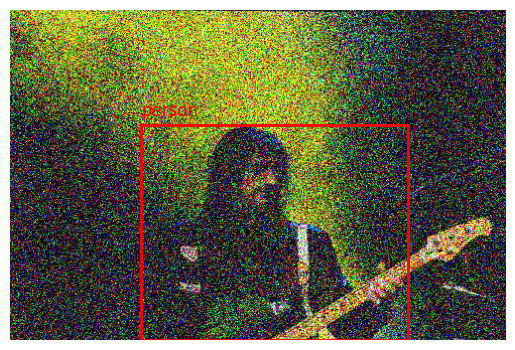

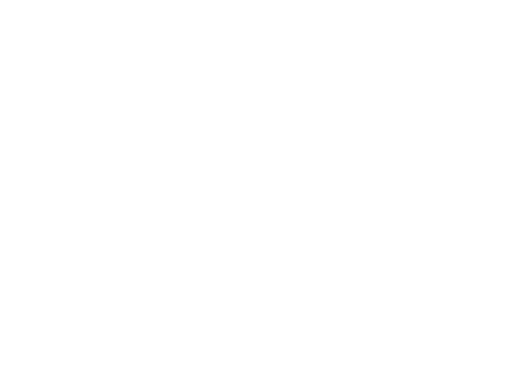

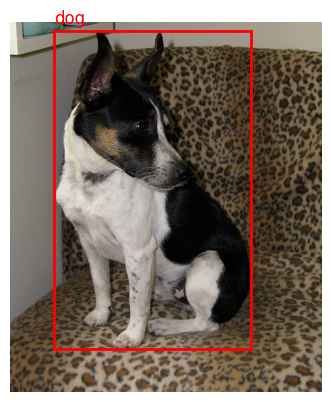

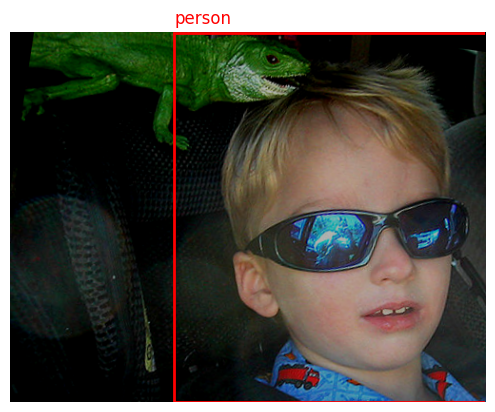

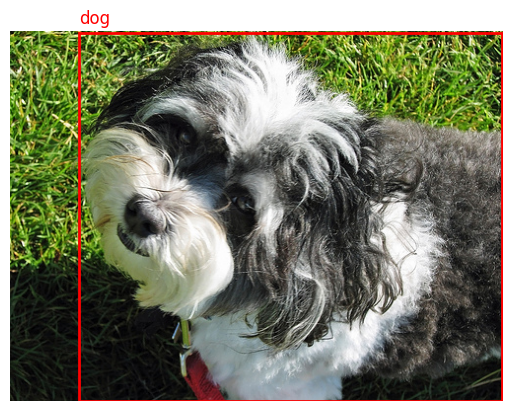

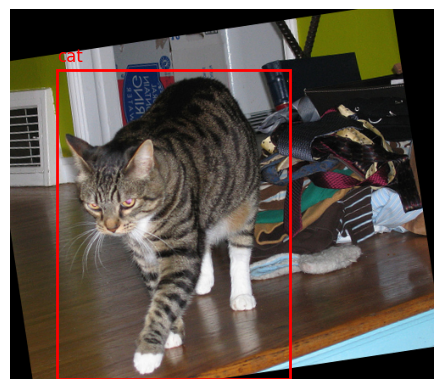

In [6]:
from dataloader import  build_visualized_loader,build_dataloader, albumentations_transform

train_loader = build_visualized_loader(
    data_root="final_public/public",
    split="train",
    transforms=albumentations_transform(),
)


def visualize_batch(images, labels):
    import matplotlib.pyplot as plt
    #images là 1 list
    # labels là list gồm các dict là {"boxes": boxes, "labels": labels, "image_id": img_id}
    #vẽ box lên ảnh
    labels_dict = {"person": 0, "car": 1, "dog": 2, "cat": 3, "chair": 4}
    batch_size = len(images)
    for i in range(batch_size):
        img = images[i].permute(1, 2, 0).numpy()  # Chuyển từ (C, H, W) sang (H, W, C)
        label = labels[i]
        boxes = label["boxes"]
        class_labels = label["labels"]
        for box, class_label in zip(boxes, class_labels):
            x_min, y_min, x_max, y_max = box
            class_name = list(labels_dict.keys())[list(labels_dict.values()).index(class_label)]
            # Vẽ bounding box
            plt.imshow(img)
            plt.gca().add_patch(plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                              edgecolor='red', facecolor='none', linewidth=2))
            plt.text(x_min, y_min - 10, class_name, color='red', fontsize=12)
        plt.axis('off')
        plt.show()
for i, (images, labels) in enumerate(train_loader):
    print(f"Batch {i}:")
    #print(f"  Images: {images}")
    print(f"  Labels: {labels}")
    if i == 0:  # Just visualize the first batch
        visualize_batch(images, labels)

        break
